In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rho = 2260 ## density of graphite, kg/m^3
g = 9.8 ## m/s^2
k_b = 1.38e-23 ## J/K

In [8]:
data = np.loadtxt('/Users/dcmoore/Yale University Dropbox/David Moore/uspheres/th228_engine/magnetic_potential_cyl_export_N42in_N52out_composite.txt', skiprows=9)

x_init = data[:,0]
z_init = data[:,1]
thick_init = data[:,2]
rad_init = data[:,3]
Umag_init = data[:,4]

xvals = np.unique(x_init)
zvals = np.unique(z_init)
thickvals = np.unique(thick_init)
radvals = np.unique(rad_init)

sim_dict = {}
grav_dict = {} 

for thickness in thickvals:
    curr_dict = {}
    curr_grav_dict = {}
    for radius in radvals:
        curr_dict[radius] = np.zeros((len(xvals), len(zvals)))
        curr_grav_dict[radius] = np.zeros((len(xvals), len(zvals))) 
       
        for xi, x in enumerate(xvals):
            for zi, z in enumerate(zvals):
                
                curr_grav_dict[radius][xi, zi] = rho * g * thickness * np.pi * radius**2 * (z + thickness/2)/k_b

                curr_element = Umag_init[(x_init == x) & (z_init == z) & (thick_init == thickness) & (rad_init == radius)]
                if(len(curr_element) > 1):
                    print("warning: multiple elements found for x = %f, z = %f, thickness = %f, radius = %f" % (x, z, thickness, radius))
                elif len(curr_element) == 0:
                    print("warning: no elements found for x = %f, z = %f, thickness = %f, radius = %f" % (x, z, thickness, radius))
                    curr_dict[radius][xi, zi] = np.nan
                    continue

                curr_dict[radius][xi, zi] = curr_element[0]


    sim_dict[thickness] = curr_dict
    grav_dict[thickness] = curr_grav_dict

x_array, z_array = np.meshgrid(xvals, zvals, indexing='ij')


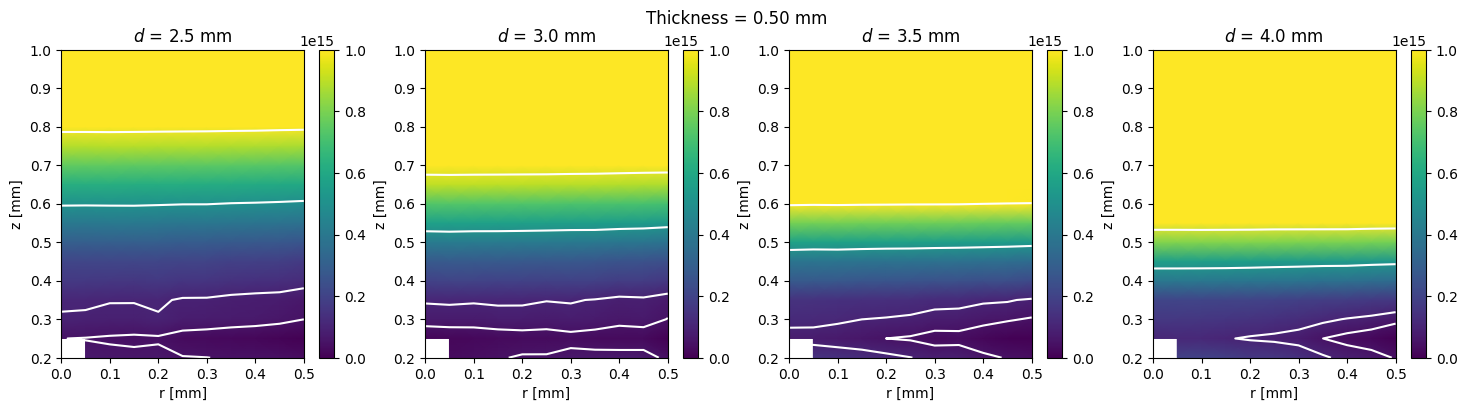

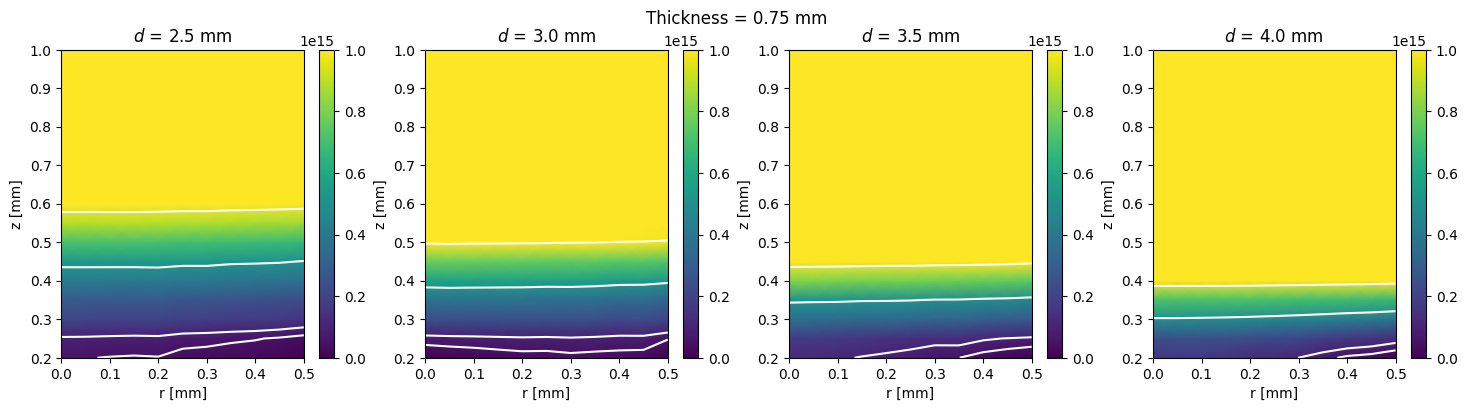

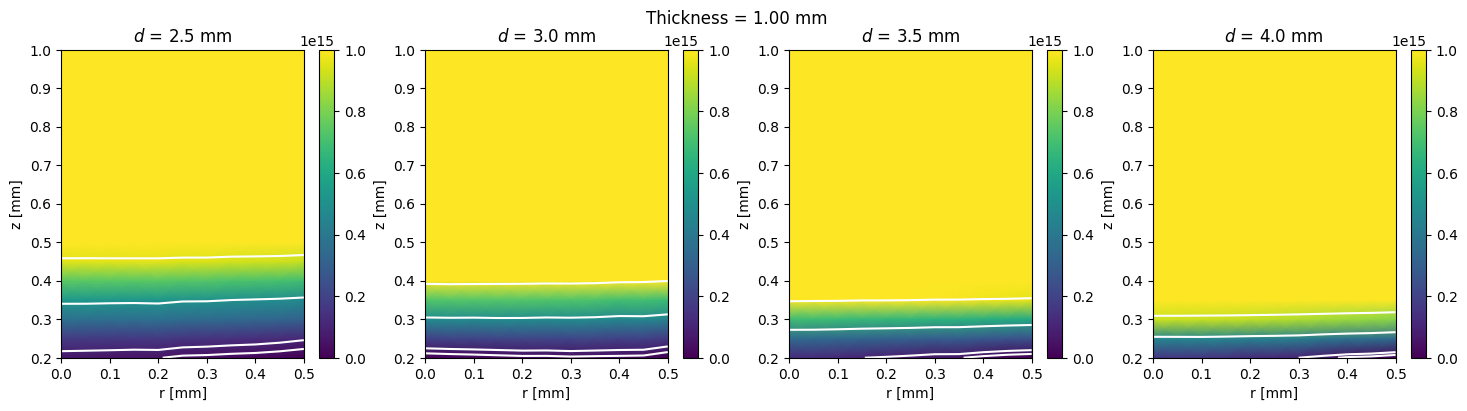

In [9]:

for thickness in thickvals:
    
    plt.figure(figsize=(18, 4))
    for ridx, radius in enumerate(radvals):
        plt.subplot(1, len(radvals), ridx+1)

        curr_U = sim_dict[thickness][radius] + grav_dict[thickness][radius]
        curr_U -= np.nanmin(curr_U)

        plt.pcolormesh(x_array*1e3, z_array*1e3, curr_U, shading='gouraud', vmin=0, vmax=1e15)
        plt.colorbar()

        plt.contour(x_array*1e3, z_array*1e3, curr_U, levels=[5e13, 1e14, 5e14, 1e15], colors='white')
        plt.title('$d$ = %.1f mm'%(2*radius*1e3))

        plt.xlabel('r [mm]')
        plt.ylabel('z [mm]')
        #plt.title('thickness = %f, radius = %f' % (thickness, radius))
    plt.suptitle('Thickness = %.2f mm' % (thickness*1e3))

plt.show()